Makemore: part 3

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
os.chdir('/Users/alexanderhannah/Desktop/Github-projects/nn-zero-to-hero')

In [3]:
# read in the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
# build the vocabulary of charcters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
# MLP revisited
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5) # gain / sqrt(fan_in)
# b1 = torch.randn(n_hidden,                        generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.01 # scale it down to decrease the logits (h @ W2) (don't set to zero)
b2 = torch.randn(vocab_size,                      generator=g) * 0 # we should intialize this at zero

# BatchNorm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

12297


When you train a NN, you should have a rough idea of what the loss is at initialization, depends on the loss function.
In this case, we expect a low-ish number that we can calculate.
27 characters that could come next.
At initialization, all characters are equally likely.
P(character) = 1/27
Loss = -log(1/27) = 3.3

If loss is higher, then probability distribution is messed up, some predictions are highly confident and wrong
Let's say we have 4 characters
Logits are close to zero and all the same
Softmax should be 4 uniform numbers (0.25)
Loss should be 1.38.

If we assign the correct probability by chance, then we'll get a low loss
We'll get a high loss if the logits are wrong or have extreme values (e.g. logits = torch.randn(4)) * 10

We want the logits to be roughly equal when the model is initialized
Record the loss we expect at initialization

Values of h need to be optimized at initialization as well.
h is 32 x 200 (examples x activations)
Most values of h are -1 and 1, with a few values between (tanh is working hard)
Before tanh, h is between -15 and 15
What happens to tanh in a backwards pass?
out.grad * (1 - t**2). We are killing the gradient if t is -1 or +1 during backpropagation.
This can lead to a 'dead neuron' if all of the columns in h are zero
A 'leaky' ReLU is less likely to suffer from this.
hpreact is too large, so it saturates the tanh, so we don't want that.
To fix it, we can scale W1 and b1.

The deeper a network is (50 layers), the more important the initialization is. 
It's possible that a network is not training at all because of this.


We want to scale weights to preserve the distribution of inputs. I.e. the distribution of preactivation outputs should have the same stdev as the input distribution.
Mathematically, if you divide by the square root of the number of inputs, you can preserve this.

How do we initialize weights so that over many layers, we preserve the activations so they don't go to zero or to very high values.
ReLU basically means that you throw away half of your distribution of values.
A paper showed the initilization scale to do this correctly.
We also need to make sure the gradients are well behaved.
If you initialize the forward pass, then the backward pass is also correctly initialized.
torch.nn.init.kaiming_normal is used commonly
We need a gain on weights so that we can boost back the squashing that happens with the tanh or relu.
Some modern innovations (residual ??, normalization layers, optimizers) make it less important to precisely calibrate the initialization.






In [ ]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
  # Linear layer
  hpreact = embcat @ W1 # + b1 # hidden layer pre-activation
  bnmeani = hpreact.mean(0, keepdim=True)
  bnstdi = hpreact.std(0, keepdim=True)
  hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias

  # BatchNorm layer
  # -------------------------------------------------------------
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  # -------------------------------------------------------------

  # Non-linearity
  h = torch.tanh(hpreact) # hidden layer
  logits = h @ W2 + b2 # output layer
  loss = F.cross_entropy(logits, Yb) # loss function
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.3147
  10000/ 200000: 2.1984
  20000/ 200000: 2.3375
  30000/ 200000: 2.4359
  40000/ 200000: 2.0119
  50000/ 200000: 2.2595
  60000/ 200000: 2.4775
  70000/ 200000: 2.1020
  80000/ 200000: 2.2788
  90000/ 200000: 2.1862
 100000/ 200000: 1.9474
 110000/ 200000: 2.3010
 120000/ 200000: 1.9837
 130000/ 200000: 2.4523
 140000/ 200000: 2.3839
 150000/ 200000: 2.1987
 160000/ 200000: 1.9733
 170000/ 200000: 1.8668
 180000/ 200000: 1.9973
 190000/ 200000: 1.8347


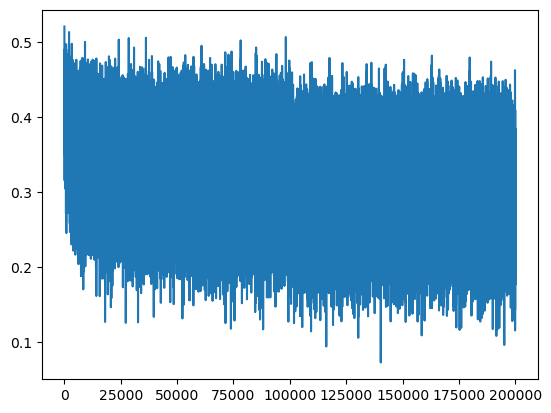

In [24]:
# hockey stick appearance can happen if in first few rounds, the logits are squashing down and rearranged (easy part), weights are being shrunk down
plt.plot(lossi)

In [ ]:
with torch.no_grad():
    # pass the training set through
    

Batch Normalization. 

We want the hpreact to be roughly gaussian. Why not just do that?

hpreact = embcat @ W1 + b1, where embcat is the inputs (embeddec characters concatenated to the right dimensions). 
if hpreact is too small, then tanh doesn't do anything, and if it's too large, then tanh is saturated and that messes with optimization (grad descent). 

We want them to only be gaussian at initialization. We want the NN to be allowed to move the neuron outputs around, and backprob to tell us how.  
bngain and bnbias allows backpropagation to work properly.  
  
With a deeper NN, it'll be tougher to tune W1 manually like we did here.  
But sprinkling batch normalization layers is easier.  

BN works well, but it has this regularizing effect; the batches are coupled mathematically. Not sure the details here.  

Summary:  
We use BN to control the statistics of activations int he NN
It's common to sprinkle it across, esp after layers that have multiplications.  
The BN internally has parameters for gain and bias, and these are changed in backpropagation.  
There's also a running mean and std that are not changed during backpropagation (use a running-mean update). 
It calcs the mean and std of the activations that are feeding into the BN layer over that batch. 
Then it centers the batch to be gaussian, then offsetting it by learned bias and gain.  
It keeps track of mean and SD of inputs in 'running'. 
That allows us to forward individual examples at run time. 

Real-world example:  
Resnet: image feeds in. 
repeating layers are blocks in a deep NN. 
Each block is called a Bottleneck block. 
They are convolutional layers. Same thing as a linear layer, except it's done in geometric patches instead of on full input.  
Then 2D batchnorm layer. 
Then a ReLU layer. 
Weight layer, normalization layer, nonlinearity. 


In [30]:
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure mean and SD over the entire training set
    bnmean = hpreact.mean(0, keepdim= True)
    bnstd = hpreact.std(0, keepdim=True)

In [34]:
@torch.no_grad()
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev), 
        'test': (Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat @ W1 + b1)
    hpreact = embcat @ W1 + b1
    # hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.06659197807312
val 2.1050572395324707


How do we feed in a single input example into the NN, if the first layer requires calculating mean and SD of the group?  
Calculate the mean and SD for the input data set and save mean and sd as fixed variables.  
  


The importance of understanding the activations, the gradients, and their statistics. Thsi is important for big NNs.  
If predictions are too confident, because activations are too messed up at the last layer, then you can get the hockey stick losses.  
We need to control the activations (don't squash to zero or go to infinity), you want these roughly gaussian throughout.  
How do we scale the W matrices and biases in the NN so everything is controlled?  
First, we scaled them manually. This is tough for bigger NNs.  
We use BN layers (could also be group, layer, etc).  
It's a layer that centers the activations using the mean and stdev. This operation is differentiable.  
Now we need gain and bias, which aren't trainable.  
Now we've coupled the training examples, now how do we do the inverse? We need to estimate mean and SD once for the whole training set.  
We fold eerything into the BN layer during training, and estaimte them in a running manner.  
No one likes this layer, it can introduce bugs, it couples examples.  
BN is very effective at controlling the statistics.  

In [87]:
# Let's train a deeper network

class Linear:

    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:

    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # different behavior if you're training or evaluating (loss or test examples)
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a running 'momentum update')
        # buffers are not part of backprob/gradient descent. The running mean/var is trained 'internally'
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training: # when we're training, we use the mean/sd from the current batch
            xmean = x.mean(0, keepdim = True)
            xvar = x.var(0, keepdim = True)
        else: # in testing, we use the running mean/var
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers only when training
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

n_embd = 10 # dimension of the character embedding vectors
n_hidden = 100 # number of nuerons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd))

# 6 layer MLP
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(           n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    layers[-1].gamma *= 0.1
    # all other layers: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5# 5/3 # This is key to keep the activations from over/under saturating

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47551


In [88]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad()
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.5 if i < 100000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([(lr*p.grad.std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break

      0/ 200000: 3.2859


layer 2 (      Tanh): mean +0.01, std 0.63, saturated: 3.25%
layer 5 (      Tanh): mean -0.00, std 0.63, saturated: 2.75%
layer 8 (      Tanh): mean -0.00, std 0.65, saturated: 2.19%
layer 11 (      Tanh): mean -0.01, std 0.64, saturated: 2.34%
layer 14 (      Tanh): mean +0.01, std 0.64, saturated: 1.94%


Text(0.5, 1.0, 'activation distribution')

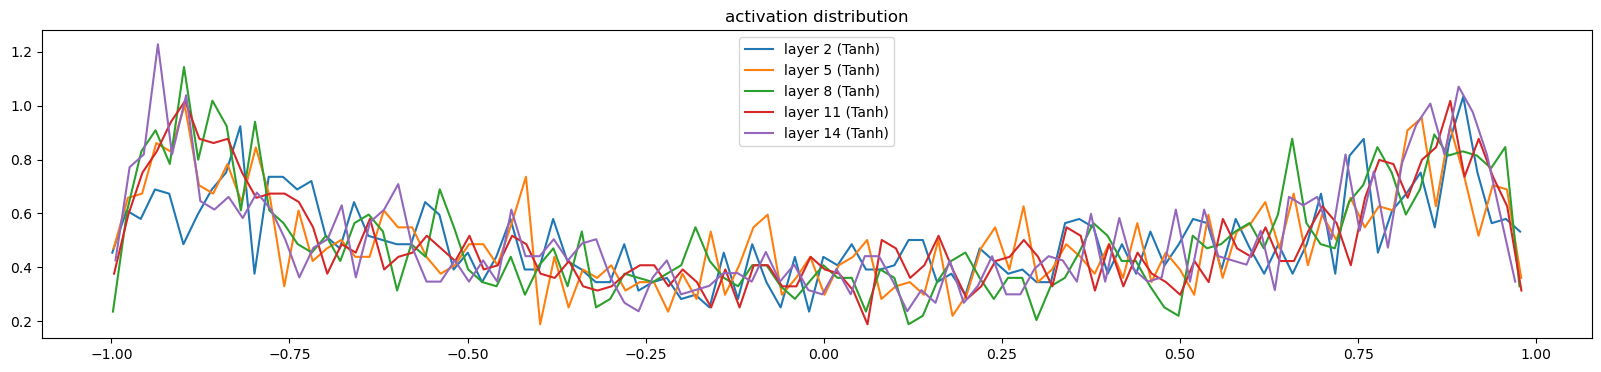

In [89]:
# visualize histograms
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 8 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 11 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 14 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

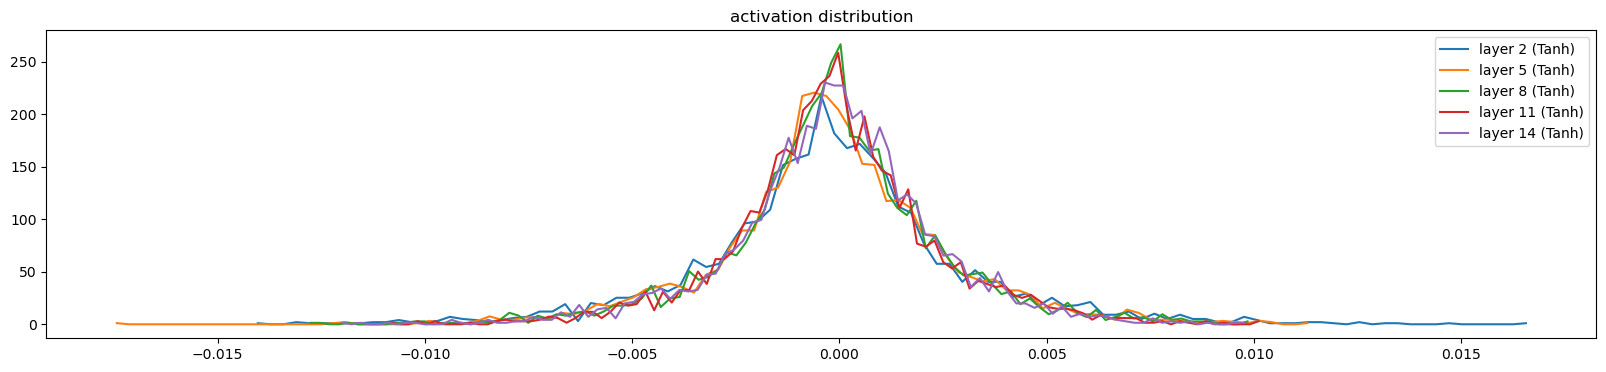

In [90]:
# layer.weight needs to be figured out


# visualize histograms
plt.figure(figsize = (20,4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends);
plt.title('activation distribution')

Without a Tanh, there's asymmetry in the NN layer to layer.  
If gain is not set correctly, we get a similar asymmetry.  

Why do we need Tanh at all?  
If you just have a stack of linear layers, it'll collapse into a single linear layer, just a linear function.  


weight   (27, 10) | mean -0.000000 | std 8.073880e-03 | grad:data ratio 7.716229e-03
weight  (30, 100) | mean -0.000007 | std 2.434956e-03 | grad:data ratio 2.634902e-03
weight (100, 100) | mean +0.000042 | std 2.135182e-03 | grad:data ratio 4.243372e-03
weight (100, 100) | mean +0.000037 | std 1.897634e-03 | grad:data ratio 3.785969e-03
weight (100, 100) | mean +0.000014 | std 1.705588e-03 | grad:data ratio 3.397980e-03
weight (100, 100) | mean -0.000007 | std 1.677831e-03 | grad:data ratio 3.320236e-03
weight  (100, 27) | mean +0.000031 | std 3.353323e-03 | grad:data ratio 6.746160e-03


Text(0.5, 1.0, 'weights gradient distribution')

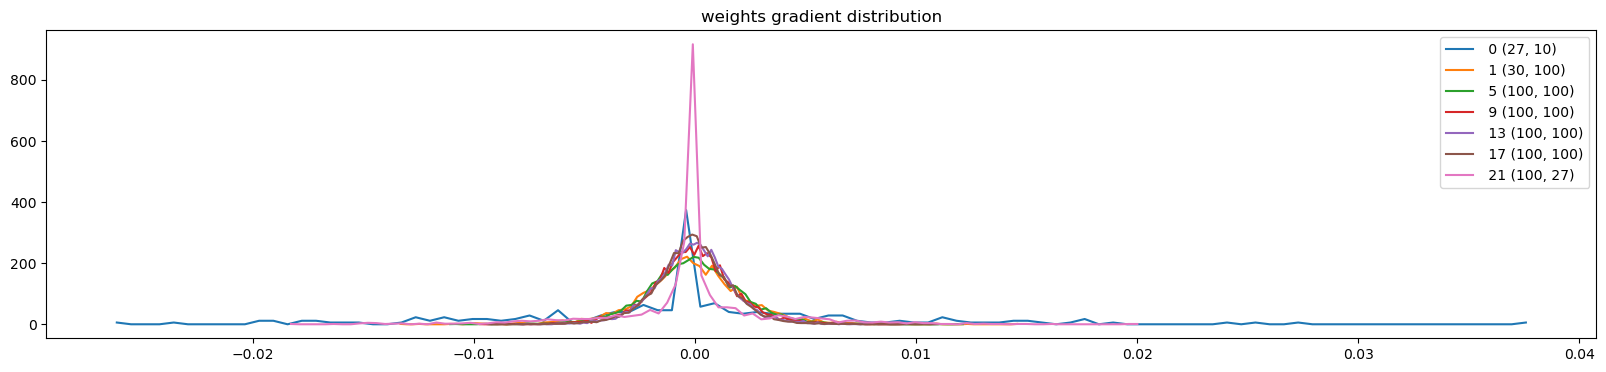

In [91]:
# visualize histograms

# What's happening with the weights
# Each layer visualized
# gradient to data ratio: what's the scale of the gradient compared to the scale of the actual values
# if gradient is too large, it's a problem. Here, the values in grad are far smaller than the data, except for the last layer


plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f' {i} {tuple(p.shape)}')
plt.legend(legends);
plt.title('weights gradient distribution')

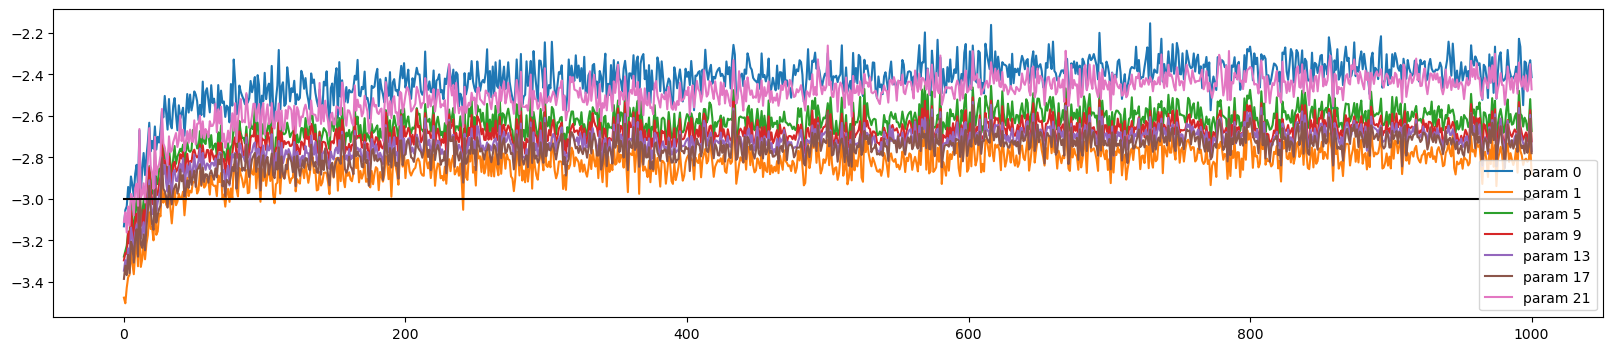

In [92]:
# Grad:data ratio is less important than the update:data ratio. This should be ~1e-3

# if this ratio is too low, then lr is probably too low

plt.figure(figsize = (20,4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k')
plt.legend(legends);

Summary:  
Learning rate, layer gain, fan_in don't have to be as fine-tuned if you introduce normalization layers (batch norm). 

